In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

In [15]:
data_path = '../data/'

orders = pd.read_csv(data_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
customers = pd.read_csv(data_path + 'olist_customers_dataset.csv')
products = pd.read_csv(data_path + 'olist_products_dataset.csv')
reviews = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')
category_translation = pd.read_csv(data_path + 'product_category_name_translation.csv')

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


In [16]:
datasets = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'reviews': reviews
}

for nome, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{nome.upper()}: {df.shape[0]:,} linhas | {df.shape[1]} colunas")
    print(f"Nulos: {df.isnull().sum().sum()}")
    print(df.dtypes)


ORDERS: 99,441 linhas | 8 colunas
Nulos: 4908
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

ORDER_ITEMS: 112,650 linhas | 7 colunas
Nulos: 0
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

CUSTOMERS: 99,441 linhas | 5 colunas
Nulos: 0
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

PRODUCTS: 32,951 linhas | 9 colunas
Nulos: 2448
product_id                     object
product_categor

In [17]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("Datas convertidas com sucesso!")
print(orders[date_columns].dtypes)

Datas convertidas com sucesso!
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [18]:
print(f"Período dos dados: {orders['order_purchase_timestamp'].min().date()} até {orders['order_purchase_timestamp'].max().date()}")
print(f"\nStatus dos pedidos:")
print(orders['order_status'].value_counts())

Período dos dados: 2016-09-04 até 2018-10-17

Status dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [19]:
receita_total = order_items['price'].sum()
ticket_medio = orders.merge(
    order_items.groupby('order_id')['price'].sum().reset_index(),
    on='order_id'
)['price'].mean()

print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Ticket médio por pedido: R$ {ticket_medio:,.2f}")
print(f"Total de itens vendidos: {order_items.shape[0]:,}")

Receita total: R$ 13,591,643.70
Ticket médio por pedido: R$ 137.75
Total de itens vendidos: 112,650


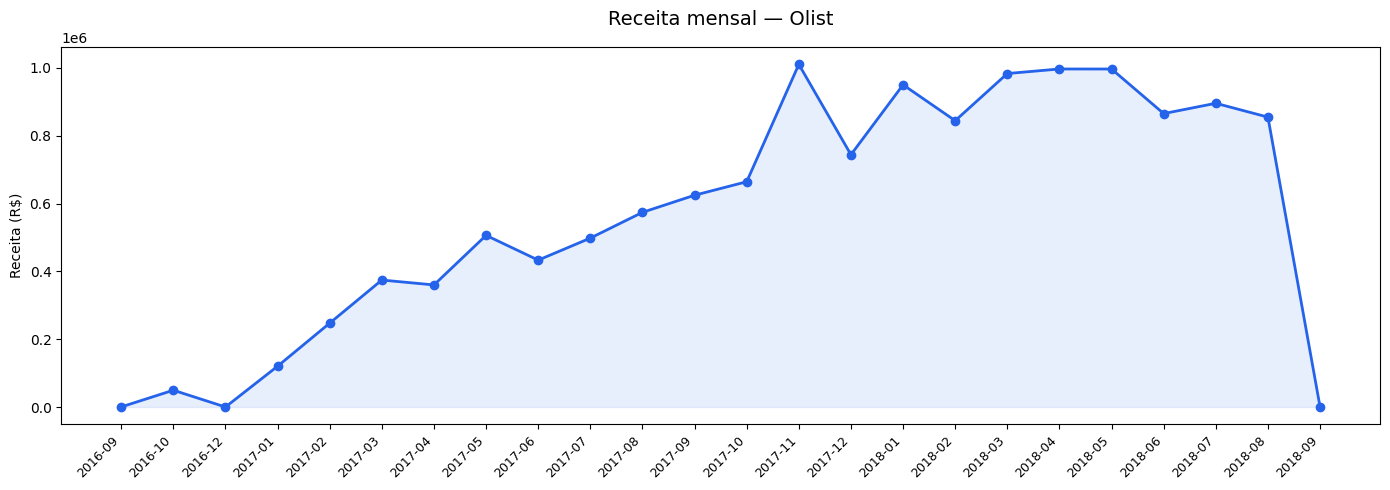

Gráfico salvo em reports/


In [20]:
orders['mes'] = orders['order_purchase_timestamp'].dt.to_period('M')

vendas_mensais = orders.merge(
    order_items.groupby('order_id')['price'].sum().reset_index(),
    on='order_id'
).groupby('mes')['price'].sum().reset_index()

vendas_mensais['mes_str'] = vendas_mensais['mes'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(vendas_mensais['mes_str'], vendas_mensais['price'], marker='o', linewidth=2, color='#2563eb')
plt.fill_between(vendas_mensais['mes_str'], vendas_mensais['price'], alpha=0.1, color='#2563eb')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Receita mensal — Olist', fontsize=14, pad=16)
plt.ylabel('Receita (R$)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../reports/vendas_mensais.png', dpi=150)
plt.show()
print("Gráfico salvo em reports/")

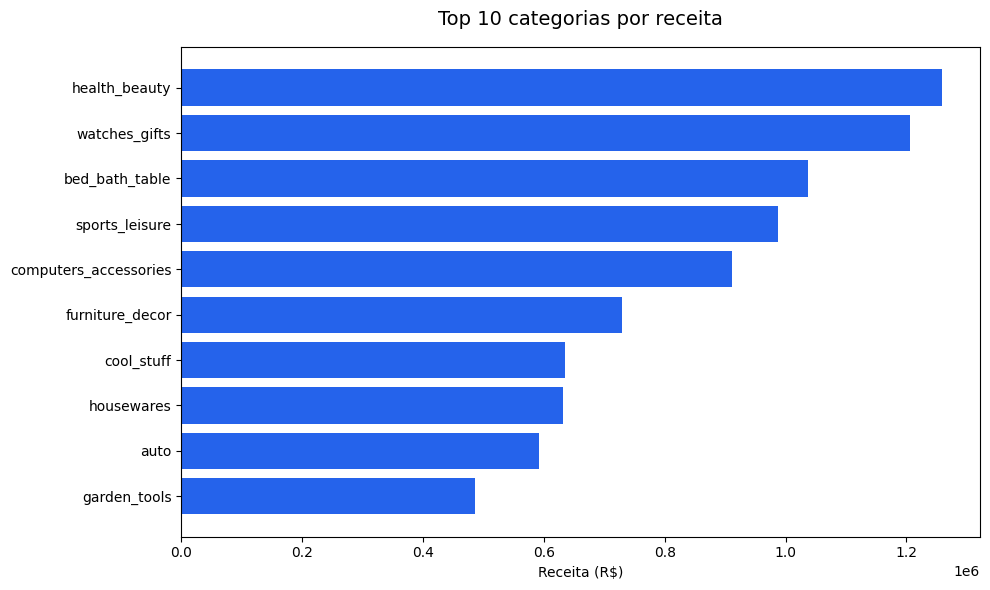

Gráfico salvo!


In [21]:
top_categorias = order_items.merge(products[['product_id', 'product_category_name']], on='product_id')
top_categorias = top_categorias.merge(category_translation, on='product_category_name')

top_categorias = (
    top_categorias.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_categorias.index, top_categorias.values, color='#2563eb')
plt.title('Top 10 categorias por receita', fontsize=14, pad=16)
plt.xlabel('Receita (R$)')
plt.tight_layout()
plt.savefig('../reports/top_categorias.png', dpi=150)
plt.show()
print("Gráfico salvo!")

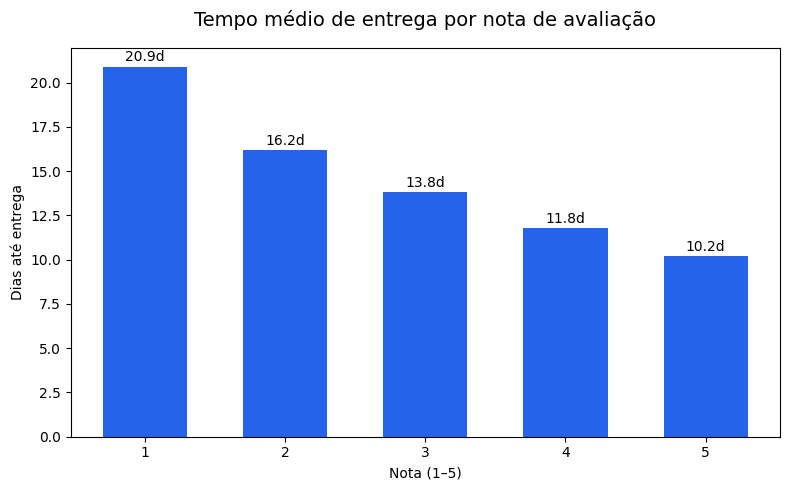


Média de dias por nota:
review_score
1    20.9
2    16.2
3    13.8
4    11.8
5    10.2
Name: dias_entrega, dtype: float64


In [22]:
entrega = orders[orders['order_delivered_customer_date'].notna()].copy()

entrega['dias_entrega'] = (
    entrega['order_delivered_customer_date'] - entrega['order_purchase_timestamp']
).dt.days

analise = entrega.merge(reviews[['order_id', 'review_score']], on='order_id')
analise = analise[analise['dias_entrega'] > 0]

media_por_nota = analise.groupby('review_score')['dias_entrega'].mean().round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(media_por_nota.index, media_por_nota.values, color='#2563eb', width=0.6)
for bar, val in zip(bars, media_por_nota.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}d', 
             ha='center', fontsize=10)
plt.title('Tempo médio de entrega por nota de avaliação', fontsize=14, pad=16)
plt.xlabel('Nota (1–5)')
plt.ylabel('Dias até entrega')
plt.tight_layout()
plt.savefig('../reports/entrega_vs_avaliacao.png', dpi=150)
plt.show()

print("\nMédia de dias por nota:")
print(media_por_nota)

In [24]:
df_powerbi = orders.merge(
    order_items.groupby('order_id').agg(
        receita=('price', 'sum'),
        qtd_itens=('order_item_id', 'count')
    ).reset_index(), on='order_id'
)

df_powerbi = df_powerbi.merge(customers[['customer_id', 'customer_state']], on='customer_id')
df_powerbi = df_powerbi.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

df_powerbi['dias_entrega'] = (
    df_powerbi['order_delivered_customer_date'] - df_powerbi['order_purchase_timestamp']
).dt.days

df_powerbi.to_csv('../data/olist_tratado.csv', index=False)
print(f"Arquivo exportado com {df_powerbi.shape[0]:,} linhas e {df_powerbi.shape[1]} colunas")

Arquivo exportado com 99,214 linhas e 14 colunas
